#  KrushiMitra - Crop Yield Prediction using Machine Learning

## Objective
The objective of this project is to predict crop yield using Machine Learning based on agricultural and geographical features such as State, District, Crop, Season, Crop Year, and Area.


## Workflow

1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Data Preprocessing
6. Model Building
7. Model Evaluation
8. Hyperparameter Tuning
9. Save Model
10. Streamlit Deployment

### Data Understanding

##### Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

#####  Load Dataset

In [7]:
df = pd.read_csv("../data/Crop_Yield.csv")
df

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75
...,...,...,...,...,...,...,...,...
345331,West Bengal,PURULIA,Wheat,2015,Rabi,855.0,1241.0,1.45
345332,West Bengal,PURULIA,Wheat,2016,Rabi,1366.0,2415.0,1.77
345333,West Bengal,PURULIA,Wheat,2017,Rabi,1052.0,2145.0,2.04
345334,West Bengal,PURULIA,Wheat,2018,Rabi,833.0,2114.0,2.54


#####  Data Analysis

In [10]:
df.head()

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75


In [11]:
df.shape

(345336, 8)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  str    
 1   District    345336 non-null  str    
 2   Crop        345327 non-null  str    
 3   Crop_Year   345336 non-null  int64  
 4   Season      345336 non-null  str    
 5   Area        345336 non-null  float64
 6   Production  340388 non-null  float64
 7   Yield       345336 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 33.6 MB


In [17]:
df.describe()

,Crop_Year,Area,Production,Yield
count,345336.000000,3.453360e+05,3.403880e+05,345336.000000
mean,2008.887512,1.167147e+04,9.584726e+05,79.423135
std,6.564361,4.584079e+04,2.153068e+07,916.678396
min,1997.000000,4.000000e-03,0.000000e+00,0.000000
25%,2003.000000,7.400000e+01,8.700000e+01,0.550000
50%,2009.000000,5.320000e+02,7.170000e+02,1.000000
75%,2015.000000,4.112000e+03,7.182000e+03,2.470000
max,2020.000000,8.580100e+06,1.597800e+09,43958.330000


In [16]:
df.describe(include='object')

,State,District,Crop,Season
count,345336,345336,345327,345336
unique,37,707,55,6
top,Uttar Pradesh,BILASPUR,Rice,Kharif
freq,44781,1244,21611,138369


In [18]:
df.isnull().sum()

State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

##### Missing Values

In [19]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_values = missing_values[missing_values["Missing Values"] > 0]

missing_values.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
Production,4948,1.43
Crop,9,0.00


In [21]:

duplicates = df.duplicated().sum()
duplicates

np.int64(0)

##### Unique Values

In [22]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values

,Unique Values
State,37
District,707
Crop,55
Crop_Year,24
Season,6
Area,47712
Production,60410
Yield,10595


In [23]:
print(df.columns.tolist())

['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area', 'Production', 'Yield']


In [30]:
df.columns = df.columns.str.strip()

In [32]:
df.dtypes

State             str
District          str
Crop              str
Crop_Year       int64
Season            str
Area          float64
Production    float64
Yield         float64
dtype: object

In [34]:
comparison = pd.DataFrame()

comparison["Actual_Yield"] = df["Yield"]

comparison["Calculated_Yield"] = df["Production"] / df["Area"]

comparison["Difference"] = (
    comparison["Actual_Yield"] -
    comparison["Calculated_Yield"]
).abs()

comparison.head()

,Actual_Yield,Calculated_Yield,Difference
0,1.40,1.399820,0.000180
1,1.40,1.400025,0.000025
2,0.74,0.737883,0.002117
3,0.64,0.641428,0.001428
4,0.75,0.751264,0.001264


In [35]:
comparison["Difference"].describe()

count    340388.000000
mean          0.003426
std           0.077483
min           0.000000
25%           0.000694
50%           0.002222
75%           0.003590
max          40.000000
Name: Difference, dtype: float64

In [36]:
comparison["Difference"].max()

np.float64(40.0)

In [38]:
df.loc[comparison["Difference"].idxmax()]

State              Kerala
District        ERNAKULAM
Crop            Sugarcane
Crop_Year            2018
Season        Whole Year 
Area                0.008
Production            1.0
Yield                85.0
Name: 148231, dtype: object

In [39]:
comparison[comparison["Difference"] > 1]

,Actual_Yield,Calculated_Yield,Difference
447,1.25,0.000000,1.250000
462,2.36,0.000000,2.360000
465,1.50,0.000000,1.500000
479,1.14,0.000000,1.140000
524,1.17,0.000000,1.170000
537,2.50,5.000000,2.500000
581,3.00,5.000000,2.000000
107231,1.67,3.333333,1.663333
112068,1.39,2.777778,1.387778
146827,15.00,25.000000,10.000000


### 2. Data Cleaning

In this phase, we improve the dataset quality by:

- Removing missing values
- Removing inconsistent records
- Validating data
- Preparing a clean dataset for EDA and Model Building

In [45]:
df_clean = df.copy()
df_clean

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75
...,...,...,...,...,...,...,...,...
345331,West Bengal,PURULIA,Wheat,2015,Rabi,855.0,1241.0,1.45
345332,West Bengal,PURULIA,Wheat,2016,Rabi,1366.0,2415.0,1.77
345333,West Bengal,PURULIA,Wheat,2017,Rabi,1052.0,2145.0,2.04
345334,West Bengal,PURULIA,Wheat,2018,Rabi,833.0,2114.0,2.54


In [ ]:
# Removing inconsistent rows where
# Yield is significantly different from
# Production / Area


df_clean = df_clean.dropna(subset=["Crop"])


In [48]:

bad_rows = comparison["Difference"] > 1

print("Rows to Remove :", bad_rows.sum())

Rows to Remove : 19


In [49]:
df_clean = df_clean.loc[~bad_rows].copy()

print(df_clean.shape)

(345308, 8)


In [50]:
df_clean.isnull().sum()

State            0
District         0
Crop             0
Crop_Year        0
Season           0
Area             0
Production    4944
Yield            0
dtype: int64

In [51]:
df_clean = df_clean.drop(columns=["Production"])

In [53]:
df_clean

,State,District,Crop,Crop_Year,Season,Area,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,0.75
...,...,...,...,...,...,...,...
345331,West Bengal,PURULIA,Wheat,2015,Rabi,855.0,1.45
345332,West Bengal,PURULIA,Wheat,2016,Rabi,1366.0,1.77
345333,West Bengal,PURULIA,Wheat,2017,Rabi,1052.0,2.04
345334,West Bengal,PURULIA,Wheat,2018,Rabi,833.0,2.54


In [55]:
df_clean.isnull().sum()

State        0
District     0
Crop         0
Crop_Year    0
Season       0
Area         0
Yield        0
dtype: int64

#### EDA

In [56]:
df_clean

,State,District,Crop,Crop_Year,Season,Area,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,0.75
...,...,...,...,...,...,...,...
345331,West Bengal,PURULIA,Wheat,2015,Rabi,855.0,1.45
345332,West Bengal,PURULIA,Wheat,2016,Rabi,1366.0,1.77
345333,West Bengal,PURULIA,Wheat,2017,Rabi,1052.0,2.04
345334,West Bengal,PURULIA,Wheat,2018,Rabi,833.0,2.54


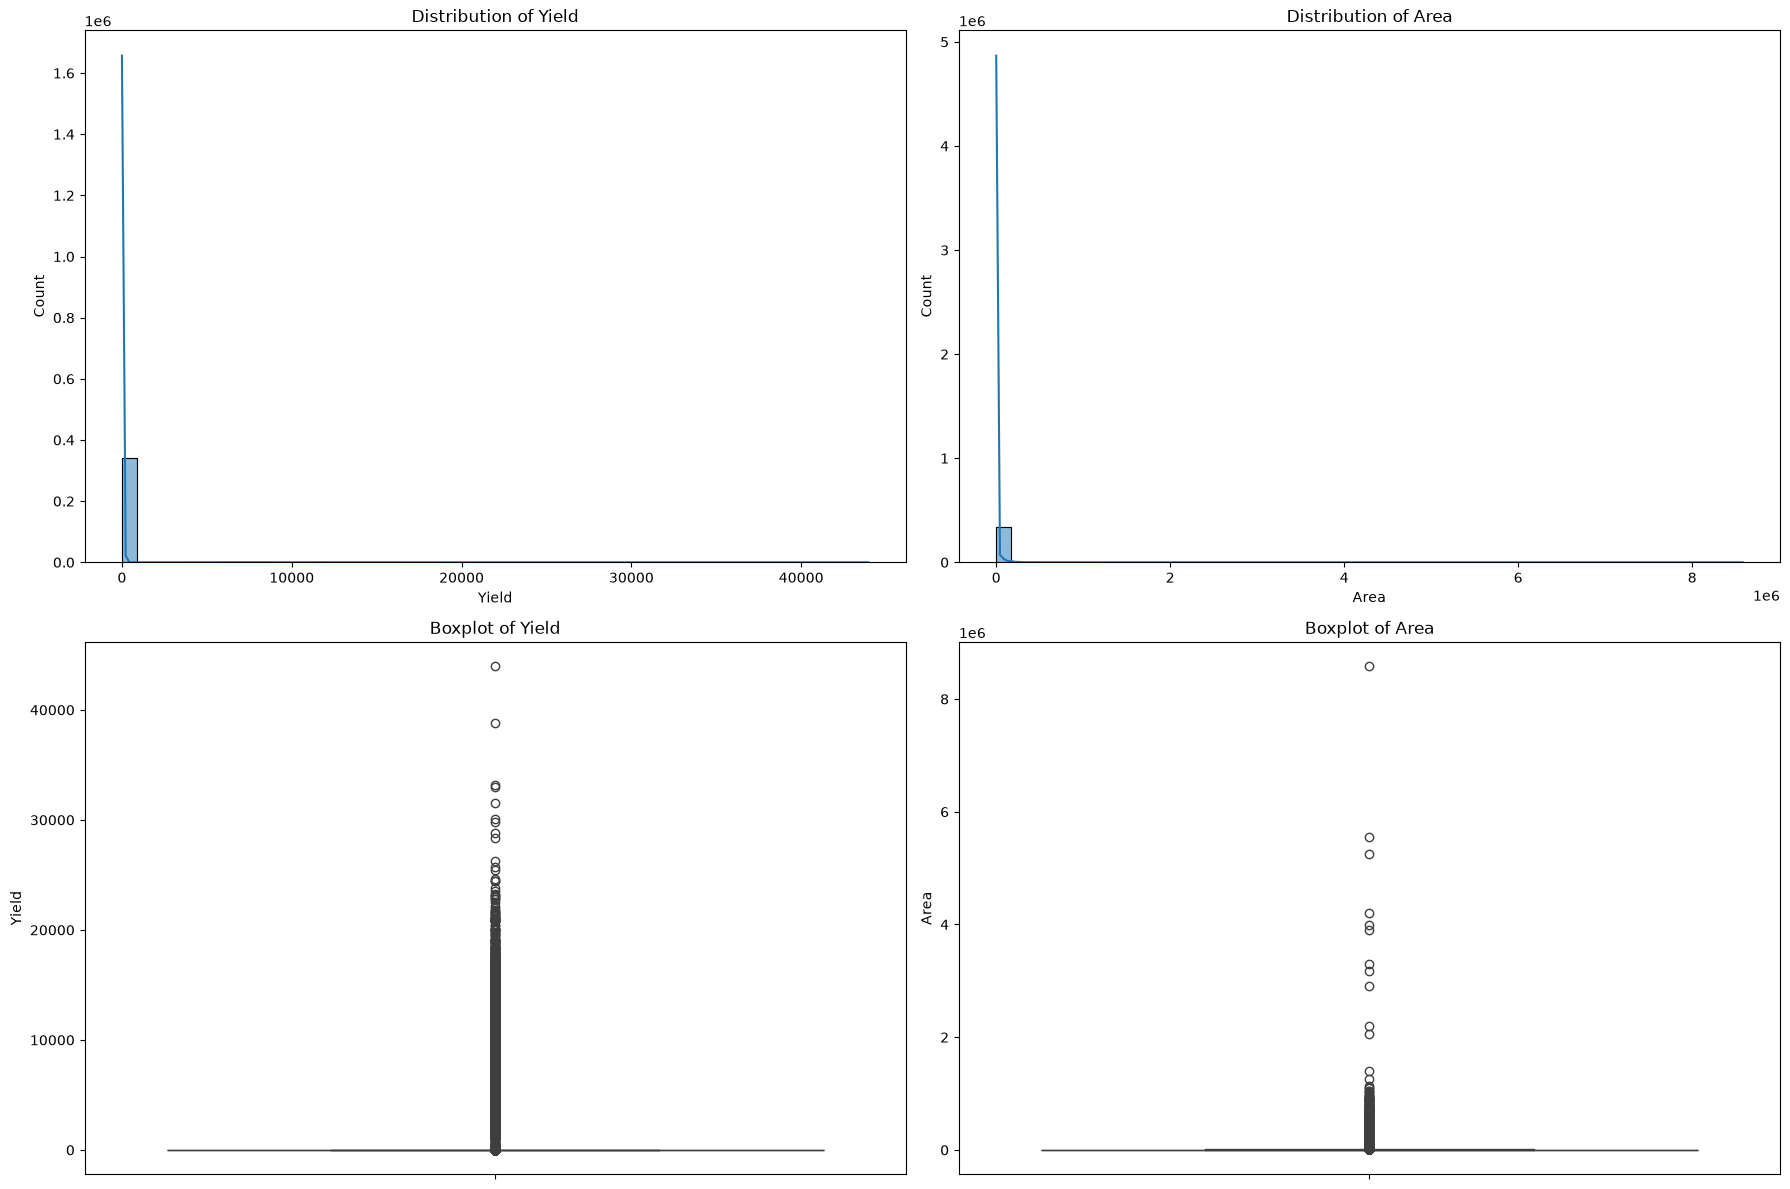

In [59]:
# Numerical Feature Analysis

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Yield Distribution
sns.histplot(
    data=df_clean,
    x="Yield",
    bins=50,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Distribution of Yield")

# Area Distribution
sns.histplot(
    data=df_clean,
    x="Area",
    bins=50,
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Distribution of Area")

# Yield Boxplot
sns.boxplot(
    y=df_clean["Yield"],
    ax=axes[1, 0]
)
axes[1, 0].set_title("Boxplot of Yield")

# Area Boxplot
sns.boxplot(
    y=df_clean["Area"],
    ax=axes[1, 1]
)
axes[1, 1].set_title("Boxplot of Area")

plt.tight_layout()
plt.show()

In [58]:
df_clean["Yield"].describe()

count    345308.000000
mean         79.428380
std         916.715338
min           0.000000
25%           0.550000
50%           1.000000
75%           2.470000
max       43958.330000
Name: Yield, dtype: float64

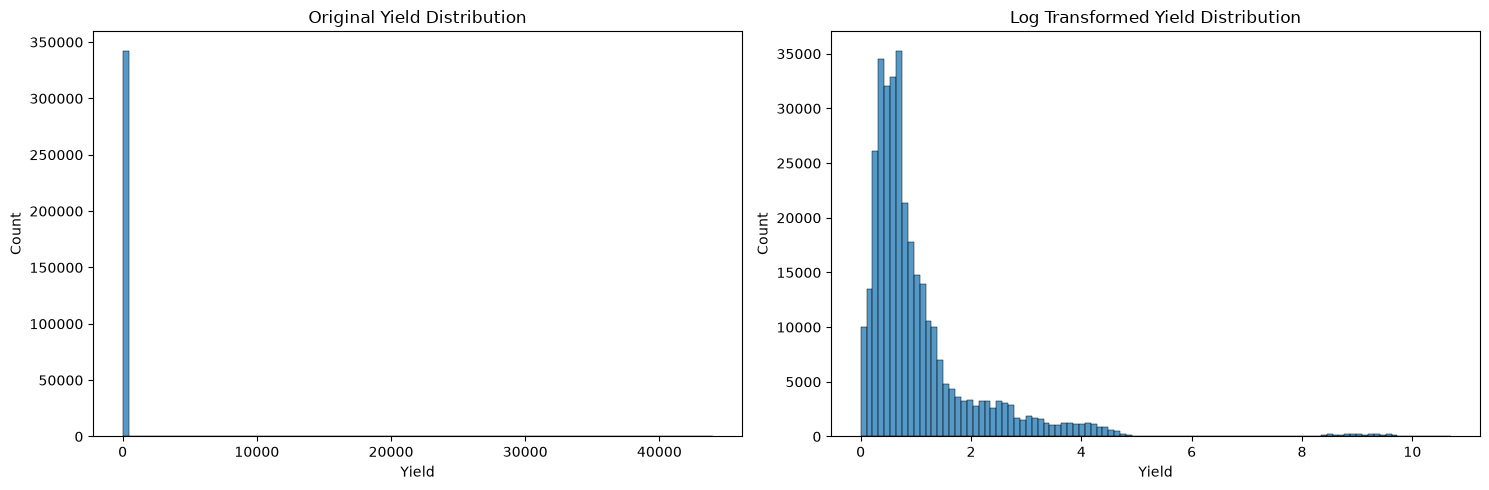

In [60]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.histplot(df_clean["Yield"], bins=100, ax=axes[0])
axes[0].set_title("Original Yield Distribution")

sns.histplot(np.log1p(df_clean["Yield"]), bins=100, ax=axes[1])
axes[1].set_title("Log Transformed Yield Distribution")

plt.tight_layout()
plt.show()

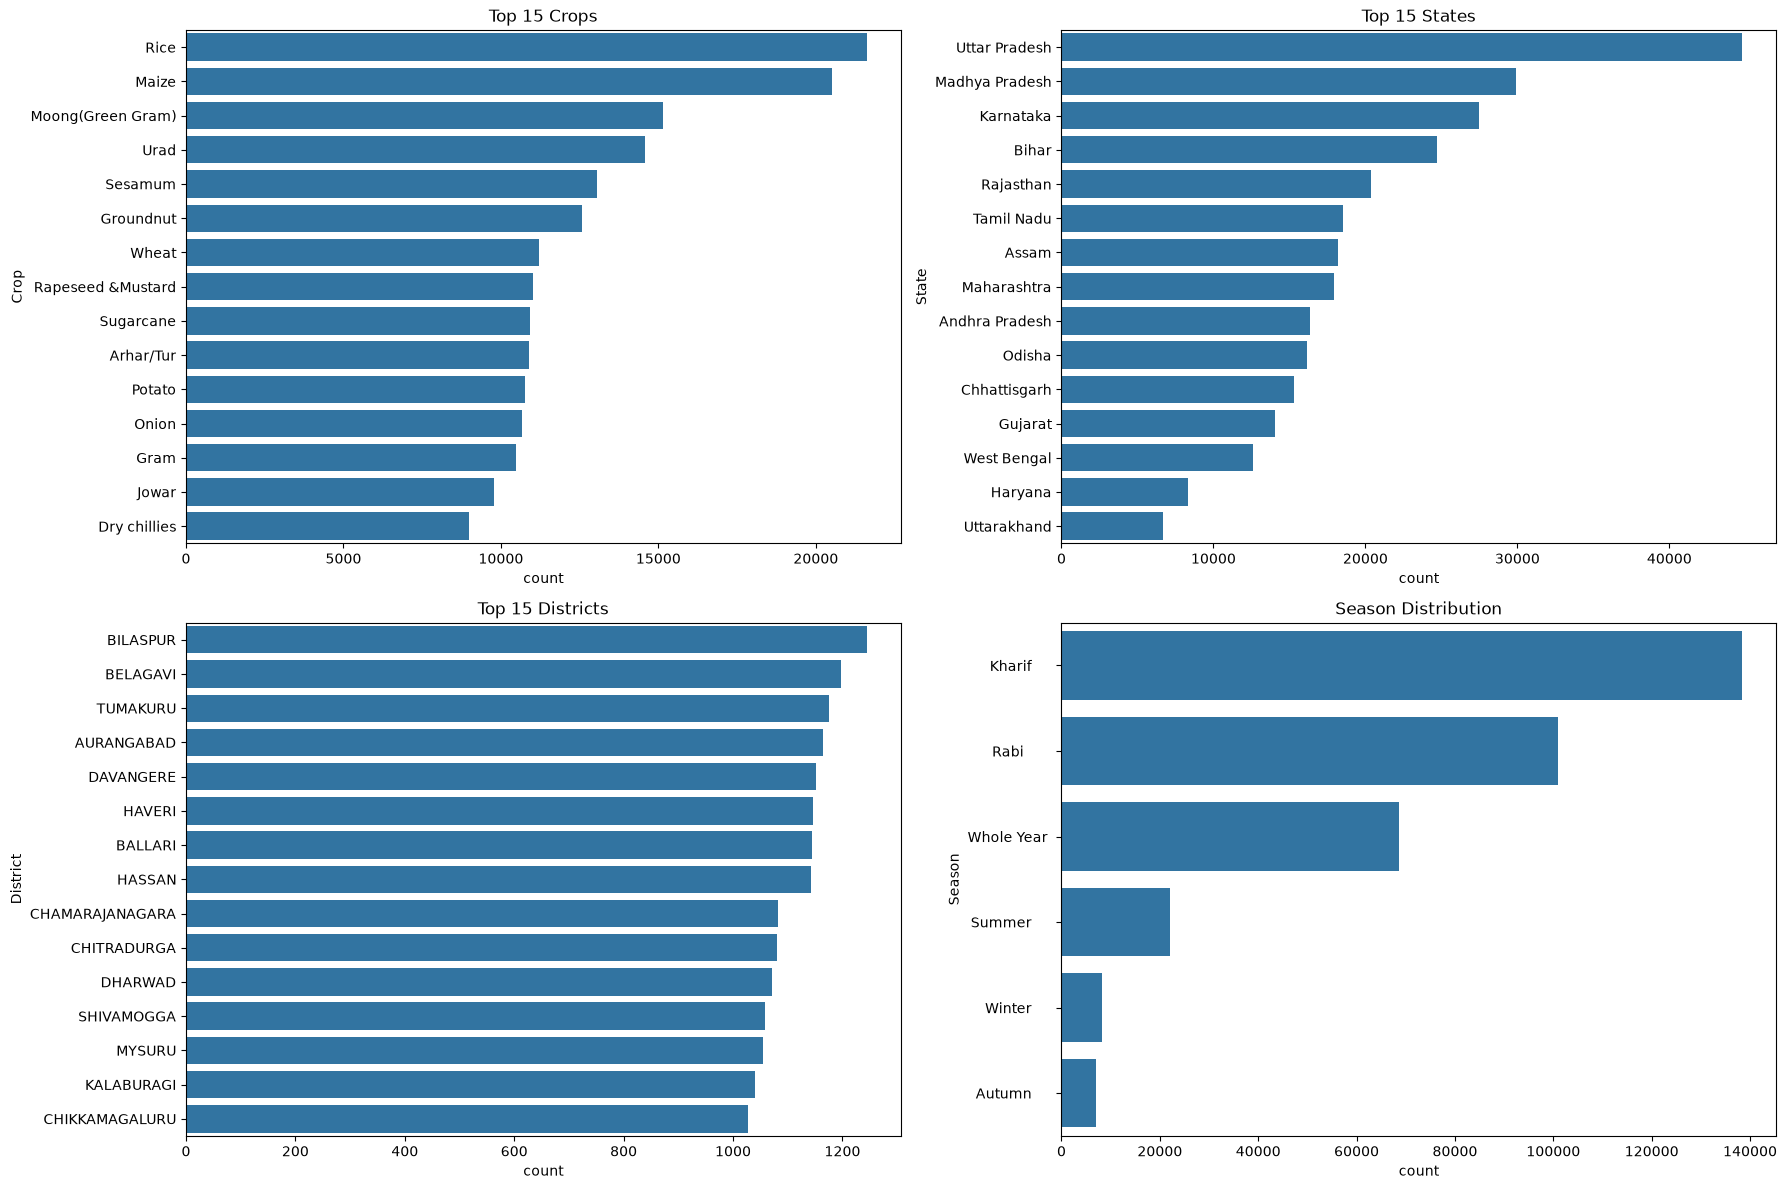

In [61]:
fig, axes = plt.subplots(2,2, figsize=(18,12))

# Top 15 Crops
sns.countplot(
    data=df_clean,
    y="Crop",
    order=df_clean["Crop"].value_counts().head(15).index,
    ax=axes[0,0]
)
axes[0,0].set_title("Top 15 Crops")

# Top 15 States
sns.countplot(
    data=df_clean,
    y="State",
    order=df_clean["State"].value_counts().head(15).index,
    ax=axes[0,1]
)
axes[0,1].set_title("Top 15 States")

# Top 15 Districts
sns.countplot(
    data=df_clean,
    y="District",
    order=df_clean["District"].value_counts().head(15).index,
    ax=axes[1,0]
)
axes[1,0].set_title("Top 15 Districts")

# Seasons
sns.countplot(
    data=df_clean,
    y="Season",
    order=df_clean["Season"].value_counts().index,
    ax=axes[1,1]
)
axes[1,1].set_title("Season Distribution")

plt.tight_layout()
plt.show()

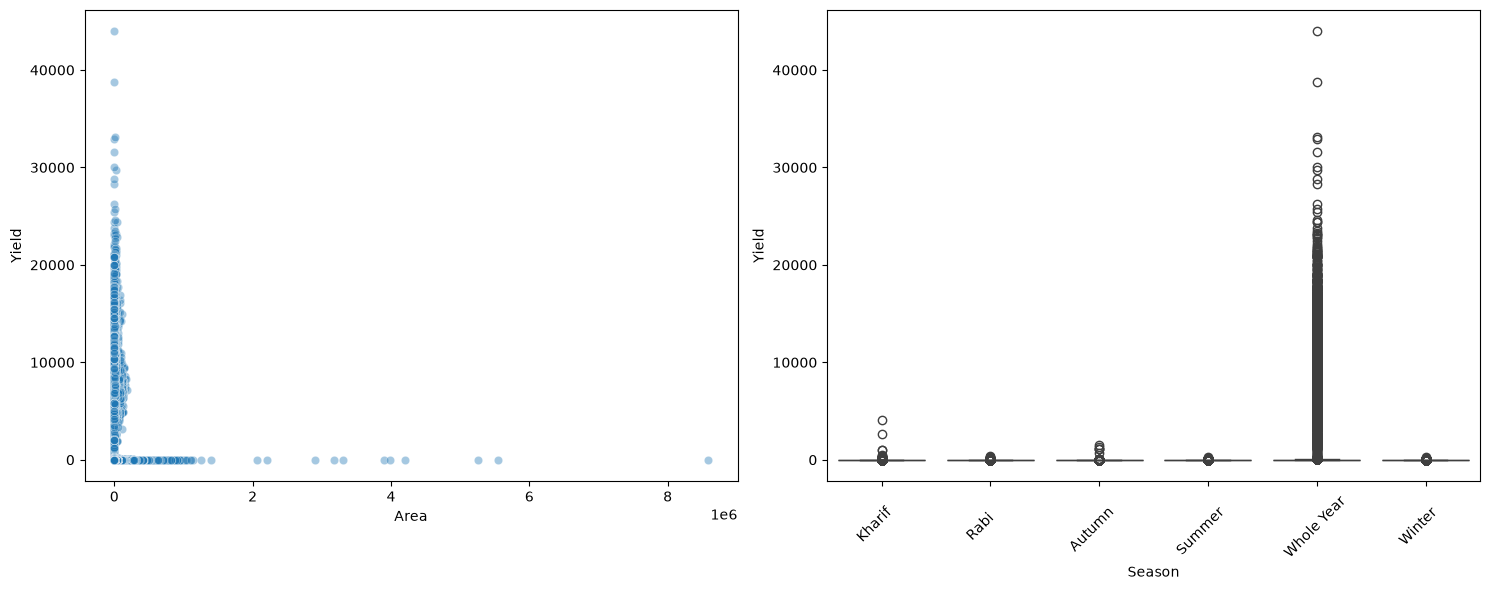

In [62]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

sns.scatterplot(
    data=df_clean,
    x="Area",
    y="Yield",
    alpha=0.4,
    ax=axes[0]
)

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield",
    ax=axes[1]
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

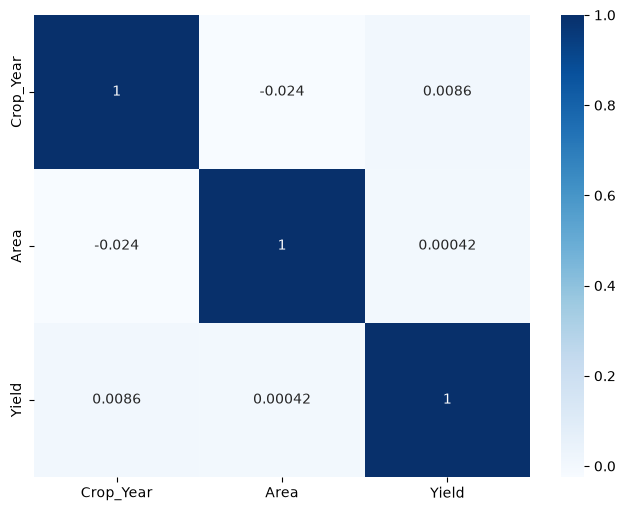

In [63]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_clean.select_dtypes(include="number").corr(),
    annot=True,
    cmap="Blues"
)

plt.show()

In [64]:
X = df_clean.drop(columns=["Yield"])

y = df_clean["Yield"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (345308, 6)
Target Shape   : (345308,)


In [65]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features :", categorical_cols)
print("Numerical Features :", numerical_cols)

Categorical Features : ['State', 'District', 'Crop', 'Season']
Numerical Features : ['Crop_Year', 'Area']


In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(276246, 807)
(69062, 807)


In [74]:
print(X_train.shape)

(276246, 807)


##### Import Machine Learning Models

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

##### Model Evaluation Metrics

In [71]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [78]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=20
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )
}

In [79]:
# Train and Evaluate Models

results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R² Score": round(r2, 4)
    })

print("Training Completed ")

Training Linear Regression...


Training Decision Tree...
Training Random Forest...
Training Completed 


In [80]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R² Score",
    ascending=False,
    inplace=True
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,MAE,RMSE,R² Score
0,Random Forest,13.723,247.545,0.9285
1,Decision Tree,16.861,322.238,0.8788
2,Linear Regression,166.911,472.296,0.7396


In [81]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 150],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the 

In [ ]:
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 20}

In [83]:
random_search.best_estimator_

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [85]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.4f}")

MAE  : 13.676
RMSE : 248.663
R²   : 0.9278


In [86]:
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [87]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

In [ ]:
pipeline.fit(X, y)

x


In [90]:
import joblib

joblib.dump(best_model, "../models/model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Model Saved Successfully ")

Model Saved Successfully 


In [91]:
loaded_model = joblib.load("../models/model.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print(type(loaded_model))
print(type(loaded_preprocessor))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [107]:
states = sorted(df_clean["State"].str.strip().unique().tolist())

state_districts = {
    state: sorted(
        df_clean[df_clean["State"].str.strip() == state]["District"]
        .str.strip()
        .unique()
        .tolist()
    )
    for state in states
}

crops = sorted(df_clean["Crop"].str.strip().unique().tolist())

seasons = sorted(df_clean["Season"].str.strip().unique().tolist())

In [108]:
# Clean categorical columns

df_clean["State"] = df_clean["State"].astype(str).str.strip()
df_clean["District"] = df_clean["District"].astype(str).str.strip()
df_clean["Crop"] = df_clean["Crop"].astype(str).str.strip()
df_clean["Season"] = df_clean["Season"].astype(str).str.strip()

In [109]:
print(df_clean["Season"].unique())

<ArrowStringArray>
['Kharif', 'Rabi', 'Autumn', 'Summer', 'Whole Year', 'Winter']
Length: 6, dtype: str


In [110]:
print(df_clean[df_clean["District"].str.contains("\n", regex=False)])

Empty DataFrame
Columns: [State, District, Crop, Crop_Year, Season, Area, Yield]
Index: []


In [111]:
with open("../data/locations.py", "w", encoding="utf-8") as f:

    f.write("# Auto-generated from training dataset\n\n")

    f.write(f"STATES = {repr(states)}\n\n")

    f.write(f"STATE_DISTRICTS = {repr(state_districts)}\n\n")

    f.write(f"CROPS = {repr(crops)}\n\n")

    f.write(f"SEASONS = {repr(seasons)}\n\n")

    f.write("""
def get_districts(state):
    return STATE_DISTRICTS.get(state, [])
""")

print("locations.py generated successfully ")

locations.py generated successfully 
